In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

#reimport
import evaluation as eval
import importlib
importlib.reload(eval)

import utils
importlib.reload(utils)

from train import * 

In [8]:
# Points dictionary
points_dict = np.load('../data/SIVE/points_dict.npy', allow_pickle=True).item()
points_dict.keys()

dict_keys(['20240623T114351_tramore', '20221211T114501_rossnowlagh', '20221204T115451_rossnowlagh', '20221116T114349_rossnowlagh', '20221007T114349_rossnowlagh', '20220922T114401_rossnowlagh', '20220910T115359_rossnowlagh', '20220905T115411_rossnowlagh', '20220813T114401_rossnowlagh', '20220811T115409_rossnowlagh', '20220722T115409_rossnowlagh', '20220607T115411_rossnowlagh', '20220604T114401_rossnowlagh', '20220523T115359_rossnowlagh', '20220408T115401_rossnowlagh', '20220326T114351_rossnowlagh', '20220319T115401_rossnowlagh', '20240211T113311_portrane', '20220323T113321_portrane', '20201002T114401_portrane', '20190707T113321_portrane', '20190207T113321_portmarnock', '20171129T113419_portmarnock', '20230904T113321_bull_island', '20230604T114349_bull_island', '20230530T114351_bull_island', '20230420T114351_bull_island', '20190920T113319_bull_island', '20190826T113321_bull_island', '20190707T113321_bull_island', '20190627T113321_bull_island', '20190501T114351_bull_island', '20190411T114

In [9]:
def plot_all_predictions(model, meta_data, test_paths, batch_size=1,crop_remove=200):
    """Plot predictions for all test data in test_paths using model and meta_data"""

    for path in test_paths:
        image,  pred_full = eval.get_combined_pred(model,meta_data,
                                                   points_dict, 
                                                   path, 
                                                   batch_size=1,
                                                   post_process=False,
                                                   threshold=None,
                                                   binary=False
                                                   )
        image = image[:,crop_remove:-crop_remove, crop_remove:-crop_remove]
        pred_full = pred_full[crop_remove:-crop_remove, crop_remove:-crop_remove]

        ID = os.path.basename(path).split('.')[0]
        points = points_dict[ID][1]

        fig, ax = plt.subplots(1, 3, figsize=(12, 6))
        rgb_image = utils.get_rgb(image, r=0,b=2,contrast=0.3)
        rgb_image = utils.enhance_rgb(rgb_image,1.5)



        ax[0].imshow(rgb_image)
        ax[0].set_title("RGB Image")
        
        ax[1].imshow(1-image[-1], cmap='gray')
        ax[1].set_title("Target")

        ax[2].imshow(1-pred_full, cmap='gray')
        ax[2].set_title("Prediction")

        for a in ax:
            a.set_xticks([])
            a.set_yticks([])
        
        plt.show()

In [10]:
# Test data
target_pos = -1

test_file = '../data/SIVE/test_1/'
test_paths = glob.glob(test_file + '*.npy')
test_targets = [np.load(file)[target_pos] for file in test_paths]
test_input = [np.load(file)[0:target_pos] for file in test_paths]

print("Test dimensions:")
print(np.shape(test_targets[0]))
print(np.shape(test_input[0]))

Test dimensions:
(750, 650)
(5, 750, 650)


Model metadata:
name: SIVE_04JUN2025_HED_SimpleCNN_trainable_guided_wBCE.pth
date: 04JUN2025
arcitecture: HED
backbone: SimpleCNN
freeze_backbone: trainable
guidance: True
loss_function: wBCE


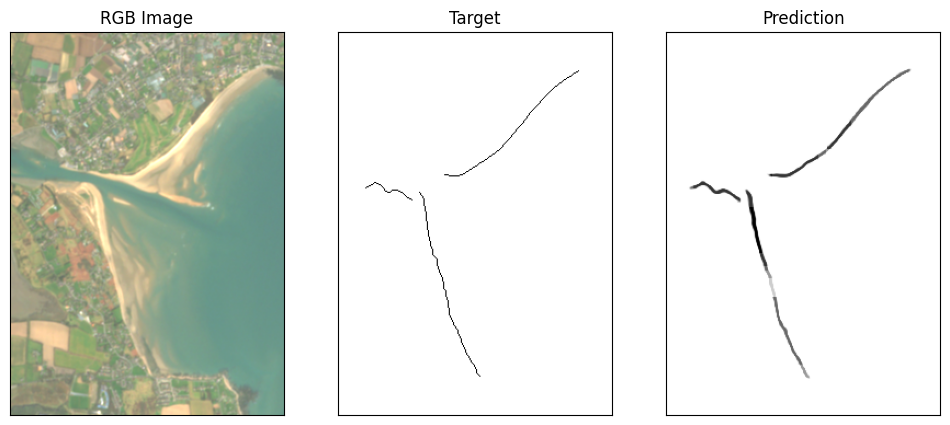

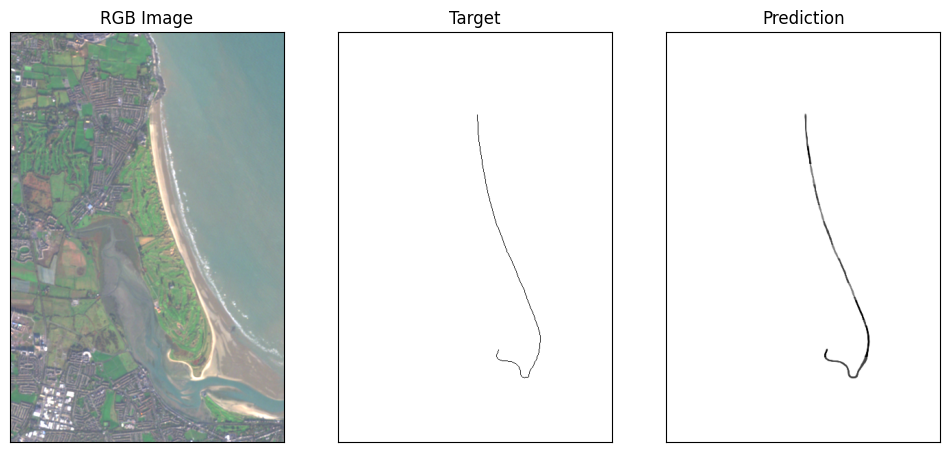

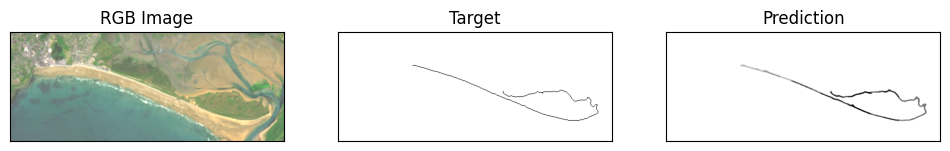

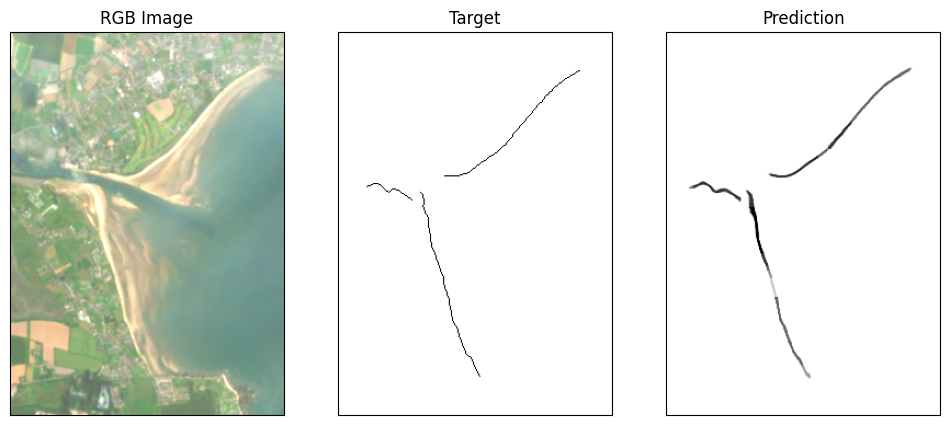

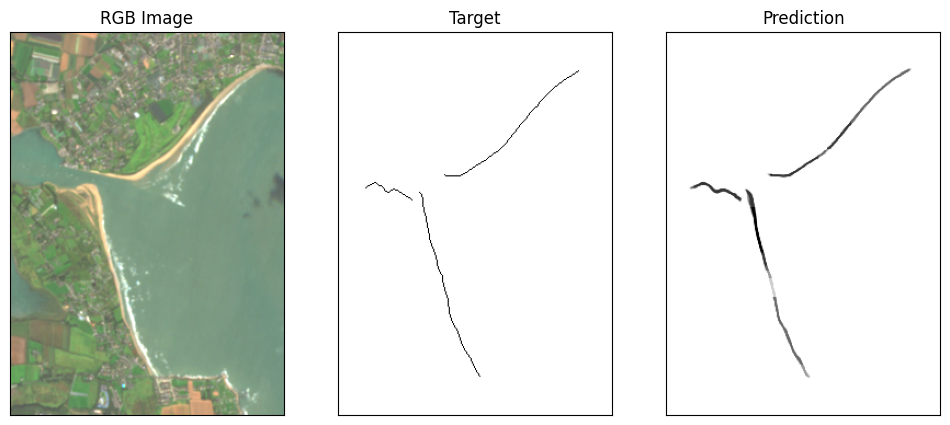

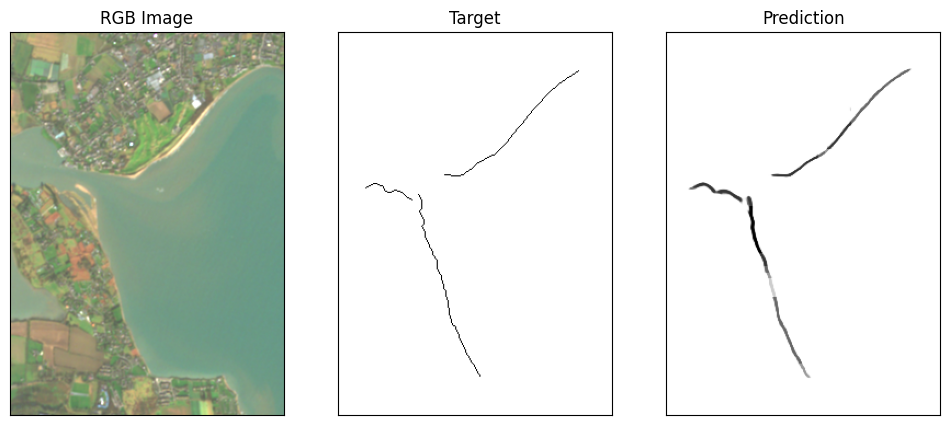

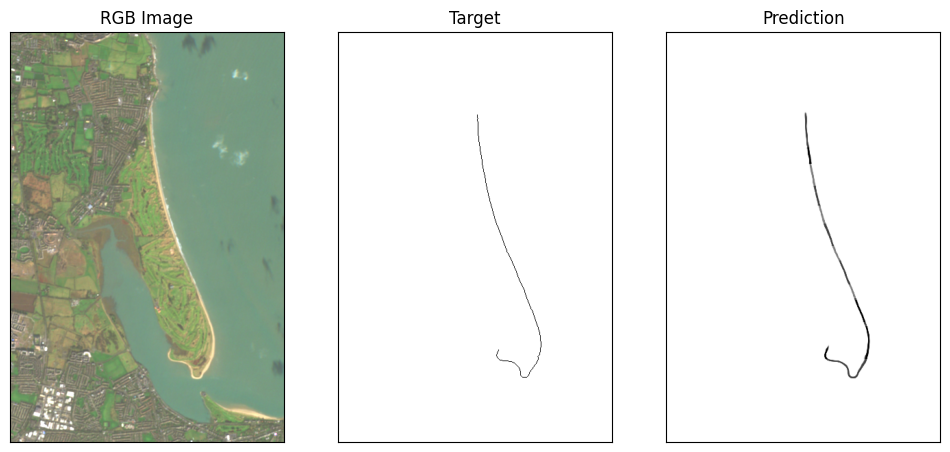

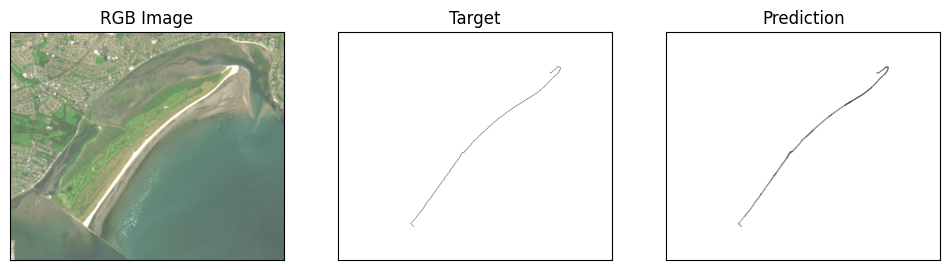

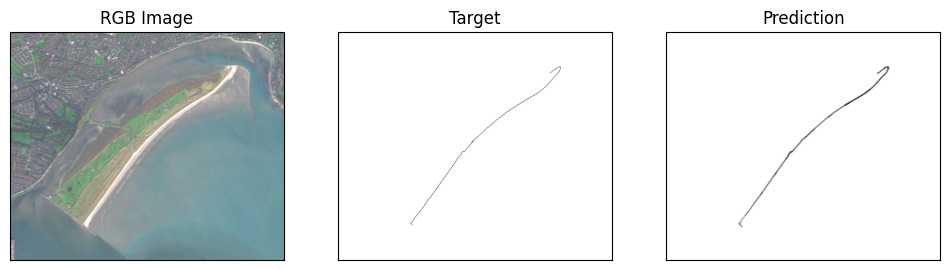

In [ ]:
model_name = "SIVE_04JUN2025_HED_SimpleCNN_trainable_guided_wBCE.pth"

model_path = f'../models/SIVE_04JUN2025/{model_name}'
model, meta_data = utils.get_model(model_path)

print("Model metadata:")
for key, value in meta_data.items():
    print(f"{key}: {value}")

plot_all_predictions(model, meta_data, test_paths)

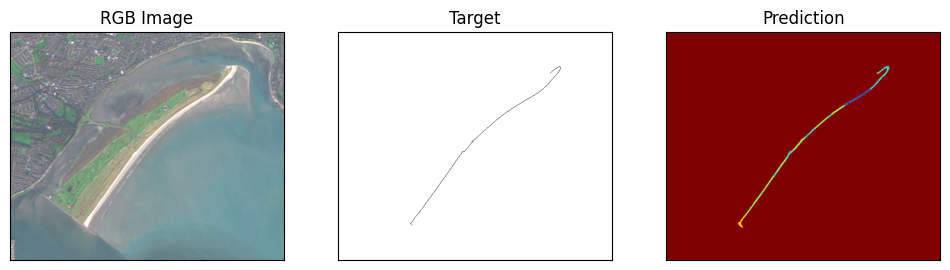

In [14]:
path = test_paths[-1]
crop_remove = 200


image,  pred_full = eval.get_combined_pred(model,meta_data,
                                                   points_dict, 
                                                   path, 
                                                   batch_size=1,
                                                   post_process=False,
                                                   threshold=None,
                                                   binary=False
                                                   )
image = image[:,crop_remove:-crop_remove, crop_remove:-crop_remove]
pred_full = pred_full[crop_remove:-crop_remove, crop_remove:-crop_remove]

ID = os.path.basename(path).split('.')[0]
points = points_dict[ID][1]

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
rgb_image = utils.get_rgb(image, r=0,b=2,contrast=0.3)
rgb_image = utils.enhance_rgb(rgb_image,1.5)



ax[0].imshow(rgb_image)
ax[0].set_title("RGB Image")

ax[1].imshow(1-image[-1], cmap='gray')
ax[1].set_title("Target")

ax[2].imshow(1-pred_full, cmap='jet')
ax[2].set_title("Prediction")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])